In [6]:
from dotenv import load_dotenv
load_dotenv("../.env")

True

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

AI_MODEL = "gemini-3-flash-preview"

llm = ChatGoogleGenerativeAI(model=AI_MODEL)

/home/ar0ne/Codes/llm-agents-playground/graph/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [16]:
from typing import TypedDict, Annotated
from operator import add

class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list[str], add]

In [17]:
from tavily import TavilyClient

tavily = TavilyClient()

def search_web(state: State):
    """search web for input question"""
    search_docs = tavily.search(state['question'], max_results=3)
    
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>' 
            for doc in search_docs['results']
        ]
    )

    return {"context": [formatted_search_docs]}               

# search_web(State(question="How big is Moon?"))

In [18]:
from langchain_community.document_loaders import WikipediaLoader

def search_wiki(state: State):
    search_docs = WikipediaLoader(query=state['question'], 
                                  load_max_docs=2).load()

    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

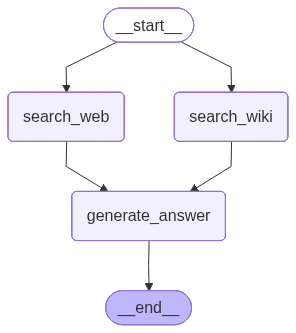

In [27]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain.messages import HumanMessage, SystemMessage

def generate_answer(state: State):

    system_msg = SystemMessage(content=f"""
        You are helpful assistent. Answer the question {state['question']} using this context: {state['context']}
    """)

    answer = llm.invoke([system_msg] + [HumanMessage("Answer the question.")])

    return {"answer": answer}

builder = StateGraph(State)
builder.add_node("search_web", search_web)
builder.add_node("search_wiki", search_wiki)
builder.add_node("generate_answer", generate_answer)

builder.add_edge(START, "search_web")
builder.add_edge(START, "search_wiki")
builder.add_edge("search_wiki", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
graph.invoke({"question": "What is the size of the Moon?"})

{'question': 'What is the size of the Moon?',
 'answer': AIMessage(content=[{'type': 'text', 'text': "Based on the provided documents, the size of the Moon can be described through several measurements and comparisons:\n\n*   **Diameter:** The Moon has a diameter of approximately **2,159 miles (3,474 to 3,475 kilometers)**.\n*   **Comparison to Earth:** It is roughly **one-quarter (1/4)** the diameter of Earth. If Earth were the size of a basketball, the Moon would be about the size of a tennis ball. It is approximately as wide as the contiguous United States.\n*   **Mass:** The Moon's mass is **1.2%** of Earth's mass. While it is the fifth-largest and fifth-most massive moon in the solar system, it is the largest and most massive in relation to its parent planet.\n*   **Gravity:** Its surface gravity is about **one-sixth** of Earth's (and about half that of Mars).\n*   **Apparent Size:** From Earth, the Moon's apparent size in the sky is about the same as that of the Sun, which allows